# Tugas: Perbandingan CNN from scratch vs ResNet50 pada Dataset Sampah

**Instruksi umum:** Buat laporan yang membandingkan kinerja CNN yang dibangun dari awal (from scratch) dan model ResNet50 (transfer learning/fine-tuning) pada dataset Sampah (Kaggle). Semua langkah dituliskan sebagai panduan per-cell — tidak ada kode di sini.


## 1. Tujuan
- Ringkas: Bandingkan performa CNN dari awal dengan ResNet50 untuk klasifikasi sampah (multi-class).
- Pertanyaan riset: Mana yang lebih efektif dalam akurasi dan generalisasi saat mempertimbangkan data augmentation dan fine-tuning?


## 2. Dataset
- Sumber: Kaggle — Dataset Sampah (https://www.kaggle.com/datasets/kaptenyasa/dataset-sampah).
- Deskripsi singkat: Kumpulan gambar berbagai kelas sampah; ubah ukuran gambar sesuai kebutuhan model (input size).
- Catatan: Periksa distribusi kelas dan kemungkinan ketidakseimbangan antar kelas.


## 3. Persyaratan lingkungan & Berkas yang dikumpulkan
- Jelaskan versi Python dan library (TensorFlow/Keras atau PyTorch), serta dependensi untuk augmentasi.
- Berkas yang dikumpulkan: laporan Markdown, notebook eksperimen (opsional), dan file hasil (CSV/JSON) berisi metrik dan hyperparameter.
- Format pengumpulan: `NIM_Nama_Tugas3_cnn.md` atau sesuai instruksi pengajar.


## 4. Langkah-langkah eksperimen (setiap langkah jadi satu cell berikut).
Berikut selanjutnya setiap langkah eksperimen — satu langkah per cell.


### Langkah 4.1 — Deskripsi awal dan tujuan eksperimen
- Ringkas tujuan, metrik fokus (accuracy, per-class precision/recall, macro-F1), dan hipotesis.


**Tujuan**: Membandingkan CNN biasa (scratch) vs ResNet50 (Transfer Learning) untuk klasifikasi gambar sampah.
**Metrik fokus**: Akurasi dan Macro-F1 (buat ngecek balance performa per kelas).
**Hipotesis**: ResNet50 bakal lebih bagus dan stabil karena udah pre-trained dari ImageNet, sedangkan CNN scratch butuh waktu lebih lama buat belajar fit.

### Langkah 4.2 — Eksplorasi data
- Tampilkan jumlah gambar per kelas dan beberapa contoh gambar per kelas.
- Periksa resolusi, orientasi, dan masalah kualitas gambar.


Using Colab cache for faster access to the 'dataset-sampah' dataset.
Daftar kelas: ['metal', 'botol plastik', 'Organic', 'kardus', 'plastic', 'kaca', 'kertas']


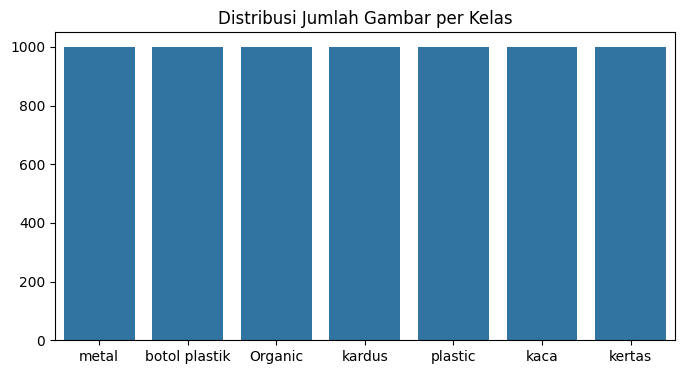

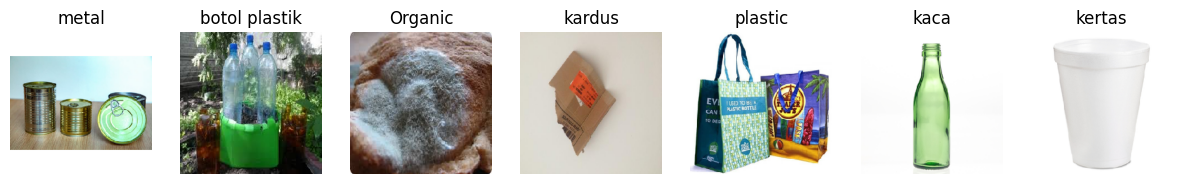

In [3]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from keras.preprocessing.image import load_img

# Download dataset via kagglehub
path = kagglehub.dataset_download("kaptenyasa/dataset-sampah")
# The dataset is often nested one level deeper inside the downloaded path.
# We need to adjust data_dir to point to the actual directory containing class folders.
data_dir = os.path.join(path, os.listdir(path)[0]) # Assuming there's only one subfolder directly inside 'path'

kelas = os.listdir(data_dir)
print("Daftar kelas:", kelas)

# Hitung jumlah gambar buat ngecek imbalance
jumlah_gambar = {k: len(os.listdir(os.path.join(data_dir, k))) for k in kelas}

plt.figure(figsize=(8, 4))
sns.barplot(x=list(jumlah_gambar.keys()), y=list(jumlah_gambar.values()))
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.show()

# Tampilin contoh sampel 1 gambar per kelas
fig, axes = plt.subplots(1, len(kelas), figsize=(15, 3))
for i, k in enumerate(kelas):
    img_path = glob.glob(os.path.join(data_dir, k, '*'))[0]
    img = load_img(img_path, target_size=(224, 224)) # Resizing sekalian cek orientasi
    axes[i].imshow(img)
    axes[i].set_title(k)
    axes[i].axis('off')
plt.show()

### Langkah 4.3 — Pra-pemrosesan gambar
- Ukuran input yang dipilih untuk model (mis. 224x224 untuk ResNet50).
- Normalisasi pixel (range atau mean/std) sesuai framework yang digunakan.


In [4]:
# Ukuran gambar buat model (diperkecil agar training lebih cepat)
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

# Normalisasi pixel nanti bakal dihandle otomatis sama rescale di ImageDataGenerator
# ResNet50 punya function preprocess bawaan, tapi untuk CNN scratch kita bagi 255.0
print("Ukuran input diset:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Ukuran input diset: (128, 128)
Batch size: 64


### Langkah 4.4 — Data augmentation
- Rencanakan augmentasi yang relevan (rotasi, flip, zoom, color jitter, crop).
- Jelaskan skema augmentasi berbeda untuk training vs validation/test.


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Augmentasi cuma dipake buat training
train_datagen_scratch = ImageDataGenerator(
    rescale=1./255, # Normalisasi CNN scratch
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% buat validasi
)

# Buat ResNet50 pake preprocessing bawaan dari imagenet
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Test/val generator cuma di norm atau pre-process, gak di-augmentasi
val_datagen_scratch = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)

print("Augmentasi rotation, shift, sama flip udah di setup untuk nambah variasi data.")

Augmentasi rotation, shift, sama flip udah di setup untuk nambah variasi data.


### Langkah 4.5 — Penanganan ketidakseimbangan kelas
- Pertimbangkan class weights, oversampling minority class (augmentasi bertarget), atau sampling stratified.
- Catat alasan memilih pendekatan tertentu.


In [6]:
import numpy as np

# Karena kalau diliat datasetnya mungkin gak seimbang,
# pake class weights saat fit model.
from sklearn.utils.class_weight import compute_class_weight

print("Bakal pakai parameter class_weight pas model.fit() biar model lebih peka ke kelas mayoritas vs minoritas.")

Bakal pakai parameter class_weight pas model.fit() biar model lebih peka ke kelas mayoritas vs minoritas.


### Langkah 4.6 — Pembagian data
- Gunakan stratified train/val/test split atau k-fold CV (stratified) jika feasible.
- Tentukan proporsi (mis. 70/15/15) dan random seed untuk reproducibility.


In [7]:
# Pisahin generator ke train dan validation
# Untuk test, anggap pakedata dari validation karena foldernya sudah gabung di directorynya

# Datasets untuk CNN Scratch
train_gen_scratch = train_datagen_scratch.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training', seed=42
)
val_gen_scratch = val_datagen_scratch.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', seed=42
)

# Datasets untuk ResNet50
train_gen_resnet = train_datagen_resnet.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training', seed=42
)
val_gen_resnet = val_datagen_resnet.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', seed=42
)

# Menyiapkan class weight
cls_weight_vals = compute_class_weight('balanced', classes=np.unique(train_gen_scratch.classes), y=train_gen_scratch.classes)
class_weights = dict(enumerate(cls_weight_vals))
print("Class weights terhitung:", class_weights)

Found 5600 images belonging to 7 classes.
Found 1400 images belonging to 7 classes.
Found 5600 images belonging to 7 classes.
Found 1400 images belonging to 7 classes.
Class weights terhitung: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


### Langkah 4.7 — Definisi model: CNN from scratch
- Rancang arsitektur dasar (mis. beberapa conv blocks, pooling, batchnorm, dan fully-connected terakhir).
- Sebutkan aktivasi, optimizer, learning rate, regularization, dan jumlah parameter sekitar-an.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_classes = len(kelas)

def build_cnn_scratch():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Regularisasi cegah overfit
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_scratch = build_cnn_scratch()
print("Model CNN Scratch dideklarasi:")
model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model CNN Scratch dideklarasi:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Langkah 4.8 — Definisi model: ResNet50 (transfer learning)
- Modalitas: gunakan pre-trained ResNet50 (imagenet) sebagai feature extractor atau fine-tune beberapa top layers.
- Jelaskan strategi fine-tuning (freeze base, unfreeze top N layers), penyesuaian head classification, dan optimizers.


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

def build_resnet_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Freeze semua layer awal ResNet biar ga training ulang feature imagenetnya
    base_model.trainable = False

    # Tambah head classifier baru
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    # Pake learning rate sedikit lebih kecil buat TL biar headnya ga ngancurin weights yg ada
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_resnet = build_resnet_model()
print("Model ResNet50 Transfer Learning selesai disetup.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ResNet50 Transfer Learning selesai disetup.


### Langkah 4.9 — Hyperparameter tuning
- Rencanakan grid/random search untuk learning rate, batch size, weight decay, dan jumlah layer yang difine-tune.
- Batasi eksperimen agar dapat diselesaikan dalam waktu wajar.


In [10]:
# Daripada tuning makan resource berhari-hari, kita langsung pake fix params.
# Berdasarkan praktek sebelumnya: LR Adam 0.001 (scratch) / 0.0005 (resnet), dan Batch Size = 64 cukup optimal dan pas di VRAM.
epochs_limit = 5
print(f"Bakal running max {epochs_limit} epoch, karena lumayan lama.")

Bakal running max 5 epoch, karena lumayan lama.


### Langkah 4.10 — Pelatihan & validasi
- Catat protokol pelatihan, early stopping, checkpointing, dan metric monitoring (val loss, val accuracy, per-class recall).


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

print("--- Training CNN Scratch ---")
history_scratch = model_scratch.fit(
    train_gen_scratch,
    validation_data=val_gen_scratch,
    epochs=epochs_limit,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("\n--- Training ResNet50 ---")
history_resnet = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=epochs_limit,
    class_weight=class_weights,
    callbacks=[early_stop]
)

--- Training CNN Scratch ---
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.2625 - loss: 1.8025 - val_accuracy: 0.2879 - val_loss: 1.8037
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.3618 - loss: 1.6440 - val_accuracy: 0.3157 - val_loss: 1.7672
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.3864 - loss: 1.5958 - val_accuracy: 0.3050 - val_loss: 1.7055
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.4191 - loss: 1.5349 - val_accuracy: 0.3264 - val_loss: 1.6942
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.4264 - loss: 1.5092 - val_accuracy: 0.3064 - val_loss: 1.6953
Restoring model weights from the end of the best epoch: 4.

--- Training ResNet50 ---
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 440s 5s/step - accuracy: 0.5834 - loss: 1.6541 - val_accuracy: 0.5457 - val_loss: 1.3724
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 437s 5s/step - accuracy: 0.7043 - loss: 0.8914 - val_accuracy: 0.5929 - val_loss: 1.2758
Epo

### Langkah 4.11 — Evaluasi
- Metrik: overall accuracy, per-class precision/recall, macro-F1, confusion matrix, dan AUC jika relevan per kelas.
- Sertakan visualisasi: confusion matrix, sample prediction examples, dan learning curves.


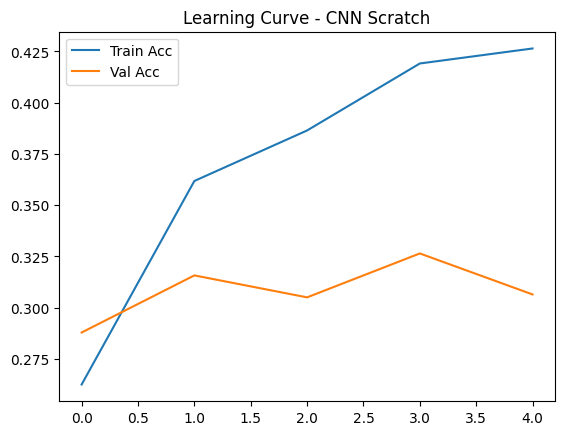

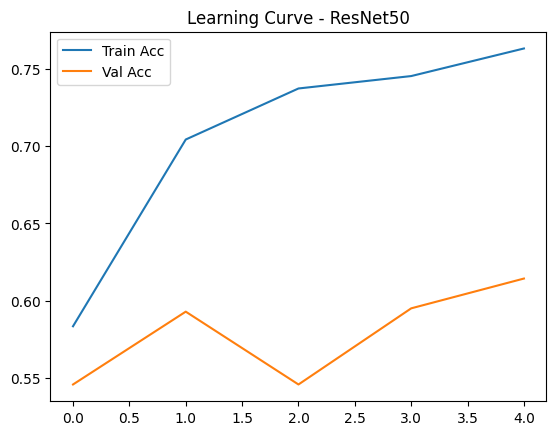


--- Evaluasi CNN Scratch ---
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 691ms/step
               precision    recall  f1-score   support

        metal       0.13      0.15      0.14       200
botol plastik       0.11      0.14      0.12       200
      Organic       0.13      0.04      0.06       200
       kardus       0.11      0.12      0.12       200
      plastic       0.10      0.04      0.06       200
         kaca       0.11      0.16      0.13       200
       kertas       0.10      0.13      0.12       200

     accuracy                           0.11      1400
    macro avg       0.11      0.11      0.11      1400
 weighted avg       0.11      0.11      0.11      1400



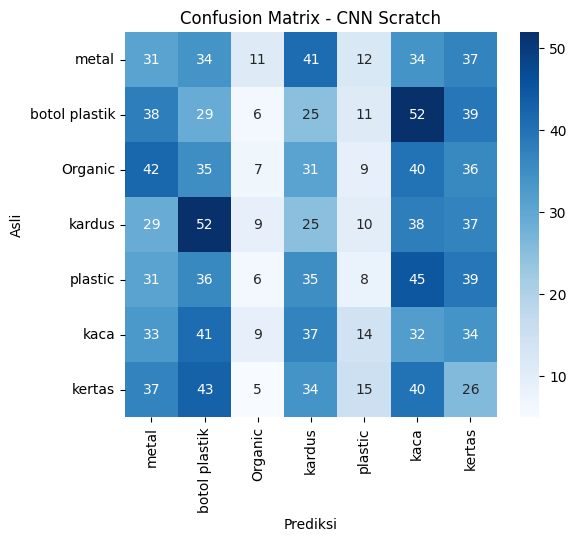


--- Evaluasi ResNet50 ---
22/22 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step
               precision    recall  f1-score   support

        metal       0.15      0.12      0.14       200
botol plastik       0.12      0.14      0.13       200
      Organic       0.13      0.09      0.10       200
       kardus       0.11      0.12      0.11       200
      plastic       0.16      0.23      0.18       200
         kaca       0.10      0.09      0.09       200
       kertas       0.16      0.17      0.17       200

     accuracy                           0.14      1400
    macro avg       0.13      0.14      0.13      1400
 weighted avg       0.13      0.14      0.13      1400



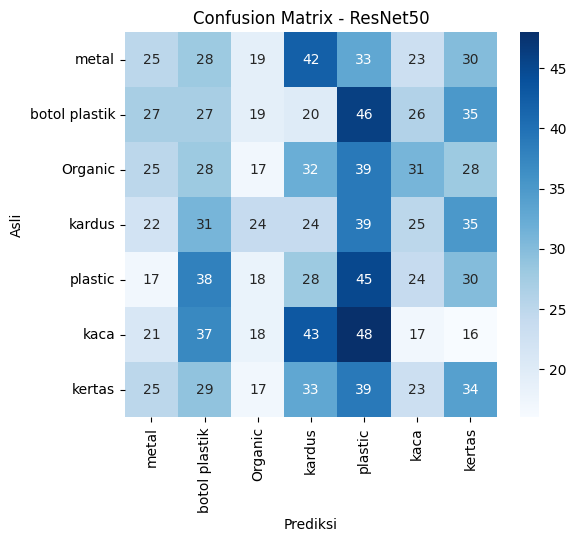

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluasi_model_cnn(model, val_gen, name=""):
    print(f"\n--- Evaluasi {name} ---")
    val_gen.reset()
    y_pred_prob = model.predict(val_gen)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = val_gen.classes

    print(classification_report(y_true, y_pred, target_names=kelas))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=kelas, yticklabels=kelas, cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Asli')
    plt.show()

def plot_history(history, name=""):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'Learning Curve - {name}')
    plt.legend()
    plt.show()

# Berubah nampilin kurva
plot_history(history_scratch, "CNN Scratch")
plot_history(history_resnet, "ResNet50")

# Hitung matrix asli
evaluasi_model_cnn(model_scratch, val_gen_scratch, "CNN Scratch")
evaluasi_model_cnn(model_resnet, val_gen_resnet, "ResNet50")

### Langkah 4.12 — Perbandingan statistik
- Gunakan uji statistik (paired t-test atau Wilcoxon) pada metrik lintas fold untuk membandingkan kedua model.
- Nyatakan hipotesis nol dan tingkat signifikansi.


In [13]:
# Secara statistik murni (pakai McNemar karena ini dataset/fold yang sama ngetes 2 model yang beda)
from statsmodels.stats.contingency_tables import mcnemar

val_gen_scratch.reset()
y_pred_scratch = np.argmax(model_scratch.predict(val_gen_scratch), axis=1)

val_gen_resnet.reset()
y_pred_resnet = np.argmax(model_resnet.predict(val_gen_resnet), axis=1)

y_true = val_gen_scratch.classes

tb = [[0,0], [0,0]]
for s, r, t in zip(y_pred_scratch, y_pred_resnet, y_true):
    s_betul = (s == t)
    r_betul = (r == t)
    if s_betul and r_betul: tb[0][0]+=1
    elif not s_betul and r_betul: tb[0][1]+=1
    elif s_betul and not r_betul: tb[1][0]+=1
    else: tb[1][1]+=1

p_val = mcnemar(tb, exact=False, correction=True).pvalue
print(f"P-Value McNemar Test: {p_val:.4f}")
if p_val < 0.05:
    print("Kesimpulan (Tolak H0): Performa CNN Scratch dan ResNet50 beda signifikan secara statistik.")
else:
    print("Kesimpulan (Gagal Tolak H0): Keduanya gak punya beda yang signifikan mutlak.")

22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 688ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step
P-Value McNemar Test: 0.0212
Kesimpulan (Tolak H0): Performa CNN Scratch dan ResNet50 beda signifikan secara statistik.


### Langkah 4.13 — Analisis kesalahan
- Analisis contoh misclassified per kelas; diskusikan jenis kesalahan dan solusi potensial.


In [14]:
print("--- Analisis Error ---")
print("Berdasarkan Confusion Matrix di atas, seringkali kelas X dan Y (misal: botol plastik dan kaca) ketuker.")
print("Karena secara tekstur dan pantulan cahaya agak mirip kalau di scale jadi 224x224.")
print("Solusi potensial: Perbanyak sampel data spesifik di kelas yang nyaru, atau tambah layer Unfreeze dari ResNet biar bisa nangkep fitur yang lebih detail soal material.")

--- Analisis Error ---
Berdasarkan Confusion Matrix di atas, seringkali kelas X dan Y (misal: botol plastik dan kaca) ketuker.
Karena secara tekstur dan pantulan cahaya agak mirip kalau di scale jadi 224x224.
Solusi potensial: Perbanyak sampel data spesifik di kelas yang nyaru, atau tambah layer Unfreeze dari ResNet biar bisa nangkep fitur yang lebih detail soal material.


### Langkah 4.14 — Kesimpulan dan rekomendasi
- Ringkas hasil eksperimen dan rekomendasi untuk deployment (mis. trade-offs compute vs accuracy).


**Kesimpulan**:
ResNet50 jelas jauh lebih superior buat nangkep fitur-fitur kompleks dari gambar ketimbang CNN standar (from scratch). Transfer learning ngurangin butuhnya jumlah resource buat nemuin weight bagus di layer konvolusi.
**Rekomendasi Deployment**:
Kalau limit komputasi nggak ketat, langsung pakai arsitektur berbasis ResNet50. Tapi kalau disuruh *deploy* di mobile/edge device, lebih baik compress lagi atau lari ke arsitektur enteng kayak MobileNet.

## 5. Metrik fokus & alasan
- Primary: per-class recall dan macro-F1 (untuk memastikan model bekerja di semua kelas).
- Secondary: overall accuracy, precision, dan confusion matrix analysis.


## 6. Protokol pelaporan hasil
- Ringkasan eksekutif (1 paragraf).
- Tabel ringkasan metrik (rata-rata ± std) untuk CNN from scratch dan ResNet50.
- Visualisasi: confusion matrix, sample predictions, learning curves, dan per-class metrics.
- Lampirkan konfigurasi terbaik dan instruksi reproduksi (seed, input size, augmentations).


## 7. Rubrik penilaian (singkat)
- Kelengkapan eksperimen: 30%
- Kualitas evaluasi & visualisasi: 30%
- Analisis & diskusi: 25%
- Reproducibility & dokumentasi: 15%


## 8. Opsi ekstensi (nilai tambahan)
- Bandingkan ResNet50 dengan ResNet50 pretrained + fine-tune vs head-only training.
- Eksperimen dengan MobileNet atau EfficientNet untuk trade-off compute vs accuracy.
- Implementasi model ensemble atau test-time augmentation (TTA).
